# Multi-delta protocol explorer, export, and heatmaps

Evaluate one protocol at one parameter node; append its complete statistics to
Excel or CSV; sweep selected timing groups using the **same settings and measurement budget**.
Edit section 2, then run sections 3–6. No direct protocol-comparison registry is used.

**Dependencies:** your existing MADI repository, Phase-1 files and signal caches;
NumPy and Matplotlib. Excel export additionally needs `openpyxl` (CSV uses only
the standard library). The simulation data are not embedded in this notebook.

**Conventions:** one acquisition row is `(delta_ms, Delta_ms, b_s_mm2, averages)`.
One average is one independent measurement. If your stored signal is a shell
average, convert its actual volume count/noise consistently before using this
convention. There is no scan-time model or time-normalized output.

## 1. Setup and shared functions

In [1]:
import sys, json, math, csv, copy, hashlib, os, tempfile, uuid
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
ARTIFACT = REPO / "data/libraries/madi_dense_universal_remediated.npz"
PHASE1_DIR = Path("/home/jaden/madi_fisher_runs/full_domain/phase1")
CACHE_DIR = Path("/home/jaden/madi_fisher_runs/full_domain/cache")
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))
from madi.fisher_crlb import canonical_grid, column_arrays, gradient_strength_t_per_m, read_column_domain
from run_fisher_phase2 import build_node_table, transposed_view

# Explicit coordinates; diagnostics below do not depend on ambiguous external CRLB labels.
PARAMETER_ORDER = ("log_rho", "log_V", "k_io")
AXES = ("rho", "V", "k_io")
SCHEMA_VERSION = "multi_delta_v1"
np.set_printoptions(precision=6, linewidth=140)

In [2]:
# ---- load: library labels, node table, column-major signal caches -----------
with np.load(ARTIFACT, allow_pickle=False) as d:
    PAIR_D  = np.asarray(d["pair_deltas"], float)      # small delta, ms
    PAIR_DD = np.asarray(d["pair_Deltas"], float)      # big Delta, ms
    B_VALUES = np.asarray(d["b_values"], float)        # s/mm^2
    N_B = int(d["n_b"])
    TABLE = build_node_table(PHASE1_DIR, d)            # nodes with all three k=1 stencils

VECTORS  = transposed_view(CACHE_DIR, "vectors")           # (column, entry)  S/S0
VARIANCE = transposed_view(CACHE_DIR, "signal_variance")   # (column, entry)  var of ensemble MEANS
N_ENS    = int(np.load(CACHE_DIR / "ensemble_means_subset.npy", mmap_mode="r").shape[1])

# The Phase-1 substrate spans every stored column, and this asserts it rather
# than trusting it: before 2026-09-06 it did not, so setting G_MAX = inf below
# could not recover the gradient-infeasible columns.  See docs/fisher_domain_audit.md.
DOMAIN   = read_column_domain(json.loads((PHASE1_DIR / "phase1_manifest.json").read_text()))
print(DOMAIN.banner())
assert DOMAIN.is_complete, "this notebook reads the model, so it needs the unrestricted substrate"
SELECTED = np.asarray(DOMAIN.column_indices, int)
POSITION = DOMAIN.position_of

RHOS, VS, KIOS, _ = canonical_grid()
NODE_RHO, NODE_V, NODE_KIO = TABLE["rho"], TABLE["V"], TABLE["kio"]
N_NODES = len(TABLE["nodes"])
AXES = ("rho", "V", "k_io")

D_COL, DD_COL, B_COL = column_arrays(PAIR_D, PAIR_DD, B_VALUES)
GRAD_COL = gradient_strength_t_per_m(D_COL, DD_COL, B_COL)   # T/m per full column

print(f"{N_NODES} nodes | {len(PAIR_D)} timing pairs x {N_B} b | n_ensembles={N_ENS}")
print(f"rho {RHOS.min():.3g}..{RHOS.max():.3g} cells/uL | V {VS.min():.3g}..{VS.max():.3g} pL "
      f"| k_io {KIOS.min():g}..{KIOS.max():g} 1/s")

COLUMN DOMAIN COMPLETE — all 31125 stored (delta, Delta, b) columns
11417 nodes | 1245 timing pairs x 25 b | n_ensembles=40
rho 1e+04..1e+07 cells/uL | V 0.01..200 pL | k_io 0..130 1/s


In [3]:
def node_at(rho, V, k_io):
    """Nearest node. rho/V matched in log space (both grids span decades)."""
    c = ((np.log(NODE_RHO) - math.log(rho)) / np.ptp(np.log(NODE_RHO))) ** 2 \
      + ((np.log(NODE_V) - math.log(V)) / np.ptp(np.log(NODE_V))) ** 2 \
      + ((NODE_KIO - k_io) / np.ptp(NODE_KIO)) ** 2
    return int(np.argmin(c))

In [4]:
_P1 = {}
def r_trunc(node):
    """|J_k1 - Richardson|/|J_k1| over all selected columns. rho and V only.

    k_io was pre-registered at k=1 alone, so it has no k=2 companion.  Returns
    None for an axis this node has no k1/k2 overlap on.
    """
    out = {}
    for axis in ("rho", "V"):
        key = tuple(int(v) for v in TABLE["nodes"][node])
        if axis not in _P1:
            s = np.load(PHASE1_DIR / f"samples_Richardson_{axis}_k1_k2.npy")
            _P1[axis] = {tuple(int(v) for v in r): i for i, r in enumerate(s)}
        row = _P1[axis].get(key)
        if row is None:
            out[axis] = None; continue
        J1  = np.asarray(np.load(PHASE1_DIR / f"J_{axis}_k1.npy", mmap_mode="r")
                         [int(TABLE["phase1_rows"][axis][node])], np.float64)
        imp = np.asarray(np.load(PHASE1_DIR / f"Richardson_{axis}_k1_k2.npy", mmap_mode="r")[row], np.float64)
        with np.errstate(divide="ignore", invalid="ignore"):
            out[axis] = np.where(J1 != 0, np.abs(J1 - imp) / np.abs(J1), np.nan)
    out["k_io"] = None
    return out

In [5]:
class ProtocolUnavailable(ValueError):
    """A requested measurement cannot be evaluated without changing its budget."""

def positive_int(value, label):
    if isinstance(value, (bool, np.bool_)):
        raise ValueError(f"{label} must be a positive integer")
    x = float(value)
    if not np.isfinite(x) or x < 1 or x != int(x):
        raise ValueError(f"{label} must be a positive integer")
    return int(x)

def resolve_protocol(acquisitions, settings):
    """Resolve exact stored columns; combine duplicate rows by adding averages.

    Never silently discard a requested column due to gradient limits or missing
    data. Such a change would invalidate the declared measurement budget.
    """
    merged = {}
    for row in acquisitions:
        if len(row) != 4:
            raise ValueError("Each row must be (delta_ms, Delta_ms, b, averages)")
        d, D, b = map(float, row[:3])
        n = positive_int(row[3], "averages")
        if not np.all(np.isfinite([d, D, b])) or min(d, D) <= 0 or b < 0:
            raise ValueError("Timings must be finite and positive; b must be finite and >= 0")
        hits = np.flatnonzero(np.isclose(PAIR_D, d, rtol=0, atol=1e-6)
                              & np.isclose(PAIR_DD, D, rtol=0, atol=1e-6))
        bs = np.flatnonzero(np.isclose(B_VALUES, b, rtol=0, atol=1e-6))
        if len(hits) != 1 or len(bs) != 1:
            raise ProtocolUnavailable(f"Timing/b not uniquely stored: {(d, D, b)}")
        p = int(hits[0]); full = p * N_B + int(bs[0])
        if POSITION[full] < 0:
            raise ProtocolUnavailable(f"Column outside cache domain: {(d, D, b)}")
        if not np.isfinite(GRAD_COL[full]) or GRAD_COL[full] > settings['g_max']:
            raise ProtocolUnavailable(f"Gradient unavailable or above G_MAX: {(d, D, b)}")
        if full in merged:
            merged[full]['averages'] += n
        else:
            merged[full] = dict(full_column=full, cache_column=int(POSITION[full]), pair=p,
                                delta_ms=float(D_COL[full]), Delta_ms=float(DD_COL[full]),
                                b_s_mm2=float(B_COL[full]), averages=n,
                                gradient_T_m=float(GRAD_COL[full]))
    rows = list(merged.values())
    if not rows:
        raise ValueError("Protocol cannot be empty")
    total = sum(r['averages'] for r in rows)
    target = settings['target_measurements']
    if target is not None and total != positive_int(target, 'target_measurements'):
        raise ValueError(f"Protocol has {total} measurements; target is {target}")
    return rows

def protocol_noise(rows, settings):
    """One common TE per protocol, or no penalty; never a TE per column."""
    mode = settings['te_mode']
    if mode not in ('fixed', 'protocol_max', 'none'):
        raise ValueError("te_mode must be 'fixed', 'protocol_max', or 'none'")
    for key in ('snr_ref', 't2_ms', 'kio_floor'):
        if not np.isfinite(settings[key]) or settings[key] <= 0:
            raise ValueError(f"{key} must be finite and positive")
    for key in ('te_overhead_ms', 'te_ref_ms', 'trust_floor', 'rician_min', 'pd_rtol'):
        if not np.isfinite(settings[key]) or settings[key] < 0:
            raise ValueError(f"{key} must be finite and nonnegative")
    if not 0 <= settings['pd_rtol'] < 1:
        raise ValueError('pd_rtol must be less than 1')
    if np.isnan(settings['g_max']) or settings['g_max'] <= 0:
        raise ValueError('g_max must be positive')
    minimum = max(r['delta_ms'] + r['Delta_ms'] for r in rows) + settings['te_overhead_ms']
    if mode == 'fixed':
        te = float(settings['te_fixed_ms'])
        if not np.isfinite(te) or te < minimum - 1e-9:
            raise ProtocolUnavailable(f"Fixed TE={te:g} ms cannot fit estimated minimum {minimum:g} ms")
    elif mode == 'protocol_max':
        te = minimum
    else:
        te = None  # No physical TE is assumed in this control calculation.
    exponent = 0.0 if te is None else (te - settings['te_ref_ms']) / settings['t2_ms']
    sigma1 = float(np.exp(exponent) / settings['snr_ref'])
    if not np.isfinite(sigma1) or sigma1 <= 0:
        raise ValueError('Noise SD overflow/underflow; inspect SNR, TE and T2')
    return te, minimum, sigma1

def spectrum(F, rtol):
    """Descending eigenvalues; matching eigenvectors are matrix columns."""
    e, Q = np.linalg.eigh((F + F.T) / 2)
    e, Q = e[::-1], Q[:, ::-1]
    # Reproducible sign convention; nearly degenerate eigenspaces still rotate.
    for j in range(3):
        if Q[np.argmax(np.abs(Q[:, j])), j] < 0:
            Q[:, j] *= -1
    tol = rtol * np.max(np.abs(e))
    positive = bool(e[-1] > tol)
    sign, logabsdet = np.linalg.slogdet(F)
    return dict(eigenvalues=e, eigenvectors=Q, rank=int(np.sum(np.abs(e) > tol)),
                positive_definite=positive, eigen_tolerance=tol,
                condition_number=float(np.linalg.cond(F)), determinant=float(np.linalg.det(F)),
                determinant_sign=float(sign), log_abs_determinant=float(logabsdet),
                log_determinant=float(logabsdet) if positive else np.nan,
                lambda1_over_lambda3=float(e[0]/e[-1]) if positive else np.nan,
                lambda3_over_lambda1=float(e[-1]/e[0]) if positive else np.nan)

def information_diagnostics(F, node, settings):
    # theta=(ln rho, ln V, k_io), q=(ln rho, ln V, k_io/k_ref).
    # dtheta/dq = D; F_q = D F_theta D and C_theta = D C_q D.
    kio = float(NODE_KIO[node]); kref = max(kio, settings['kio_floor'])
    D = np.diag([1., 1., kref])
    scaled = D @ F @ D
    native_spec = spectrum(F, settings['pd_rtol'])
    scaled_spec = spectrum(scaled, settings['pd_rtol'])
    ok = scaled_spec['positive_definite']
    C = np.full((3, 3), np.nan)
    Cs = np.full((3, 3), np.nan)
    if ok:
        L = np.linalg.cholesky(scaled)
        Linv = np.linalg.solve(L, np.eye(3))
        Cs = Linv.T @ Linv
        C = D @ Cs @ D
    var = np.diag(C).copy() if ok else np.full(3, np.inf)
    sd = np.sqrt(var)
    physical_scale = np.array([NODE_RHO[node], NODE_V[node], 1.])
    relative_sd = np.array([sd[0], sd[1], sd[2]/abs(kio) if kio != 0 else np.nan])
    relative_var = relative_sd**2
    floor_relative_sd = sd / np.array([1., 1., kref])
    kappa = np.sqrt(np.maximum(0., np.diag(F)*var)) if ok else np.full(3, np.inf)
    status = ('positive_definite' if ok else
              'indefinite' if scaled_spec['eigenvalues'][-1] < -scaled_spec['eigen_tolerance']
              else 'singular_or_below_tolerance')
    return dict(F=F, F_scaled=scaled, Finv=C, Finv_scaled=Cs,
                native_spectrum=native_spec, scaled_spectrum=scaled_spec,
                identifiable=ok, status=status, kio_ref=kref,
                crlb_variance=var, crlb_sd=sd,
                physical_crlb_variance=var*physical_scale**2,
                physical_crlb_sd=sd*physical_scale,
                relative_crlb_variance=relative_var, relative_crlb_sd=relative_sd,
                floor_relative_crlb_sd=floor_relative_sd, kappa=kappa)

def analyze_acquisition(node, acquisitions, settings):
    """Independent Gaussian information with per-column integer repetitions.

    MC derivative debiasing is inherited from the original notebook: endpoint
    covariance is omitted, so its correction can overestimate derivative noise
    and produce an indefinite F. Repeats do not shrink simulation uncertainty.
    """
    settings = copy.deepcopy(settings)
    rows = resolve_protocol(acquisitions, settings)
    te, te_min, sigma1 = protocol_noise(rows, settings)
    columns = np.array([r['cache_column'] for r in rows], int)
    averages = np.array([r['averages'] for r in rows], int)
    S = np.asarray(VECTORS[columns], np.float64)
    Svar = np.asarray(VARIANCE[columns], np.float64)
    step = np.array([TABLE[f'step_{a}'][node] for a in AXES], float)
    if not np.all(np.isfinite(step)) or np.any(step <= 0):
        raise ValueError('Invalid finite-difference step')
    Sc = S[:, TABLE['centre'][node]]
    Sm = np.stack([S[:, TABLE[f'minus_{a}'][node]] for a in AXES], axis=-1)
    Sp = np.stack([S[:, TABLE[f'plus_{a}'][node]] for a in AXES], axis=-1)
    Vm = np.stack([Svar[:, TABLE[f'minus_{a}'][node]] for a in AXES], axis=-1)
    Vp = np.stack([Svar[:, TABLE[f'plus_{a}'][node]] for a in AXES], axis=-1)
    J = (Sp - Sm) / step
    var_J = (Vp + Vm) / (N_ENS * step**2)
    if not np.all(np.isfinite(Sc)) or not np.all(np.isfinite(J)) or not np.all(np.isfinite(var_J)) or np.any(var_J < 0):
        raise ValueError('Invalid signal/Jacobian or simulation variance in cache')
    beta = np.divide(var_J, J**2, out=np.full_like(J, np.inf), where=J != 0)
    sigma = sigma1 / np.sqrt(averages)
    # Gaussian validity uses SINGLE-measurement SNR: averaging magnitude data
    # does not remove their original Rician bias. This remains a Gaussian FIM.
    keep = (Sc >= settings['trust_floor']) & (Sc >= settings['rician_min']*sigma1)
    weights = np.where(keep, averages/sigma1**2, 0.)
    F_u = J.T @ (weights[:, None]*J)
    correction = np.zeros((3, 3))
    if settings['debias']:
        correction = np.diag((weights[:, None]*var_J).sum(axis=0))
    F = F_u - correction
    amplitude_correction = np.zeros((3, 3))
    if settings['fit_s0']:
        cross = J.T @ (weights*Sc)
        amp_info = float(np.sum(weights*Sc**2))
        if amp_info > 0:
            amplitude_correction = np.outer(cross, cross)/amp_info
            F -= amplitude_correction
    F = (F + F.T)/2
    result = information_diagnostics(F, node, settings)
    result.update(node=int(node), rows=rows, settings=settings,
                  columns=columns, averages=averages, S=Sc, J=J, var_J=var_J,
                  beta=beta, step=step, keep=keep, sigma_1=sigma1, sigma=sigma,
                  te_ms=te, estimated_min_te_ms=te_min,
                  F_undebiased=F_u, debias_correction=correction,
                  amplitude_correction=amplitude_correction,
                  total_measurements=int(averages.sum()),
                  used_measurements=int(averages[keep].sum()))
    return result

## 2. Shared settings — edit here

`TE_MODE` has exactly three choices:
- `"fixed"`: use `TE_FIXED_MS` across every protocol you compare. A protocol
  exceeding this TE is rejected. Keep the value unchanged between exports.
- `"protocol_max"`: one TE for the entire protocol,
  `max(delta + Delta) + TE_OVERHEAD_MS`; all its columns get the same penalty.
- `"none"`: use `1/SNR_REF` without a TE penalty.

In the first two modes, `sigma_single = exp((TE-TE_REF_MS)/T2_MS)/SNR_REF`.
SNR refers to an unweighted **single measurement** at the reference TE.
The timing formula is an estimate: set the overhead to match your sequence.
Default 60 ms is illustrative, not a scanner-derived recommendation.

There is no implicit baseline acquisition or `N0_EFF` prior. To model estimated
S0, set `FIT_S0=True` and include actual b=0 measurements in `ACQUISITIONS` if
desired. Their repetitions count toward the same budget. With known S0,
b=0 has zero tissue-parameter information but still consumes measurements.
All non-baseline rows also inform S0 when it is estimated.

`RICIAN_MIN` is only a Gaussian-validity filter using **single-measurement** SNR;
this notebook does not implement a Rician likelihood. Masked measurements
remain in the total budget; their information is excluded and counted separately.

In [6]:
PROTOCOL_NAME = "four_timings_16_measurements"
PROTOCOL_NOTES = ""
RHO, V, K_IO = 2.5e5, 4.0, 20.0

# Each row: (delta [ms], Delta [ms], b [s/mm^2], integer averages).
# Edit each repetition count independently. Duplicate rows add their averages.
ACQUISITIONS = [
    (4.0, 15.0, 1000, 1), (4.0, 15.0, 2500, 1),
    (4.0, 15.0, 4000, 1), (4.0, 15.0, 6000, 1),
    (4.0, 25.0, 1000, 1), (4.0, 25.0, 2500, 1),
    (4.0, 25.0, 4000, 1), (4.0, 25.0, 6000, 1),
    (4.0, 30.0, 1000, 1), (4.0, 30.0, 2500, 1),
    (4.0, 30.0, 4000, 1), (4.0, 30.0, 6000, 1),
    (4.0, 40.0, 1000, 1), (4.0, 40.0, 2500, 1),
    (4.0, 40.0, 4000, 1), (4.0, 40.0, 6000, 1),
]
TARGET_MEASUREMENTS = 16       # Set None to disable the budget assertion.
TE_MODE = "protocol_max"             # "fixed" | "protocol_max" | "none"
TE_FIXED_MS = 60.0            # Shared across protocols when TE_MODE="fixed".
TE_OVERHEAD_MS = 14.0          # Sequence-specific extra time beyond delta+Delta.
TE_REF_MS = 0.0               # 0 preserves the original unattenuated SNR convention.
SNR_REF, T2_MS = 50.0, 40.0
G_MAX = np.inf                # T/m. Missing/infeasible columns are not silently dropped.
TRUST_FLOOR, RICIAN_MIN = 0.0, 0.0
DEBIAS = True
FIT_S0 = False
KIO_FLOOR = 1.0               # Scaling near k_io=0; not a true relative uncertainty.
PD_RTOL = 1e-12               # Relative numerical PD threshold in scaled coordinates.
SHOW_TRUNCATION = False       # Optional existing Richardson files for rho and V.

EXPORT_PATH = REPO / "analysis/protocol_statistics.xlsx"  # .xlsx or .csv
EXPORT_ENABLED = True        # Export cell appends this computed run once.

# Heatmap choices only; physical/noise settings above are always inherited.
HEATMAP_ENABLED = True
HEATMAP_SWEEP_GROUPS = [(4.0, 40.0)]  # Select existing timing group(s) to move together.
# Use "all" to collapse/sweep all columns as a standalone timing (same total budget).
HEATMAP_METRIC = "trace_crlb"
HEATMAP_PARAM = 0                     # 0=log_rho, 1=log_V, 2=k_io
HEATMAP_COORDINATES = "scaled"        # "scaled" or "native" for matrix metrics
HEATMAP_LOG = True
HEATMAP_VMIN, HEATMAP_VMAX = None, None
HEATMAP_MARK_EXTREMA = True


# parameter_metrics = ('crlb_variance','crlb_sd','relative_crlb_variance','relative_crlb_sd',
#                      'physical_crlb_sd','floor_relative_crlb_sd','kappa')
# matrix_metrics = ('lambda1','lambda2','lambda3','lambda1_over_lambda3',
#                   'lambda3_over_lambda1','condition_number','determinant','log_determinant')

def current_settings():
    return dict(target_measurements=TARGET_MEASUREMENTS, te_mode=TE_MODE,
                te_fixed_ms=TE_FIXED_MS, te_overhead_ms=TE_OVERHEAD_MS,
                te_ref_ms=TE_REF_MS, snr_ref=SNR_REF, t2_ms=T2_MS,
                g_max=G_MAX, trust_floor=TRUST_FLOOR, rician_min=RICIAN_MIN,
                debias=DEBIAS, fit_s0=FIT_S0, kio_floor=KIO_FLOOR, pd_rtol=PD_RTOL)

def current_snapshot():
    return dict(protocol_name=PROTOCOL_NAME, notes=PROTOCOL_NOTES,
                requested_node=[RHO, V, K_IO], acquisitions=copy.deepcopy(ACQUISITIONS),
                settings=current_settings())

def snapshot_key(snapshot):
    return hashlib.sha256(json.dumps(snapshot, sort_keys=True).encode()).hexdigest()

def require_current_result():
    if 'R' not in globals() or R['configuration_key'] != snapshot_key(current_snapshot()):
        raise RuntimeError('Settings changed or no result exists. Run section 3 before viewing/exporting/sweeping.')
    return R

## 3. Compute the selected protocol

In [7]:
if not np.all(np.isfinite([RHO, V, K_IO])) or RHO <= 0 or V <= 0 or K_IO < 0:
    raise ValueError("RHO and V must be positive; K_IO must be nonnegative")
SNAPSHOT = copy.deepcopy(current_snapshot())
NODE = node_at(RHO, V, K_IO)
R = analyze_acquisition(NODE, ACQUISITIONS, SNAPSHOT['settings'])
R.update(snapshot=SNAPSHOT, configuration_key=snapshot_key(SNAPSHOT),
         run_id=uuid.uuid4().hex, timestamp_utc=datetime.now(timezone.utc).isoformat())
RT = r_trunc(NODE) if SHOW_TRUNCATION else None
print(f"{PROTOCOL_NAME}: {R['total_measurements']} total measurements; "
      f"{R['used_measurements']} contribute after signal masks")
print(f"Requested rho/V/k_io: {RHO:g}, {V:g}, {K_IO:g}")
print(f"Actual node {NODE}: rho={NODE_RHO[NODE]:.6g}, V={NODE_V[NODE]:.6g}, k_io={NODE_KIO[NODE]:.6g}")
print(f"TE mode={TE_MODE}, TE={R['te_ms']} ms, single-measurement sigma={R['sigma_1']:.6g}")
print(f"Status: {R['status']}; scaled PD tolerance={R['scaled_spectrum']['eigen_tolerance']:.3g}")

four_timings_16_measurements: 16 total measurements; 16 contribute after signal masks
Requested rho/V/k_io: 250000, 4, 20
Actual node 5311: rho=240410, V=3.35739, k_io=20
TE mode=protocol_max, TE=58.0 ms, single-measurement sigma=0.0852623
Status: positive_definite; scaled PD tolerance=7.42e-11


## 4. Inspect the protocol

  delta  Delta       b   avg     G T/m    signal   sigma_avg   keep
    4.0   15.0    1000     1    0.2528   0.26783    0.085262   True
    4.0   15.0    2500     1    0.3997  0.055685    0.085262   True
    4.0   15.0    4000     1    0.5056  0.019829    0.085262   True
    4.0   15.0    6000     1    0.6192 0.0092504    0.085262   True
    4.0   25.0    1000     1    0.1921   0.32124    0.085262   True
    4.0   25.0    2500     1    0.3037  0.083454    0.085262   True
    4.0   25.0    4000     1    0.3842  0.030104    0.085262   True
    4.0   25.0    6000     1    0.4705  0.012543    0.085262   True
    4.0   30.0    1000     1    0.1745    0.3401    0.085262   True
    4.0   30.0    2500     1     0.276  0.096574    0.085262   True
    4.0   30.0    4000     1    0.3491  0.036174    0.085262   True
    4.0   30.0    6000     1    0.4275  0.014012    0.085262   True
    4.0   40.0    1000     1    0.1503    0.3663    0.085262   True
    4.0   40.0    2500     1    0.2376   0.11815

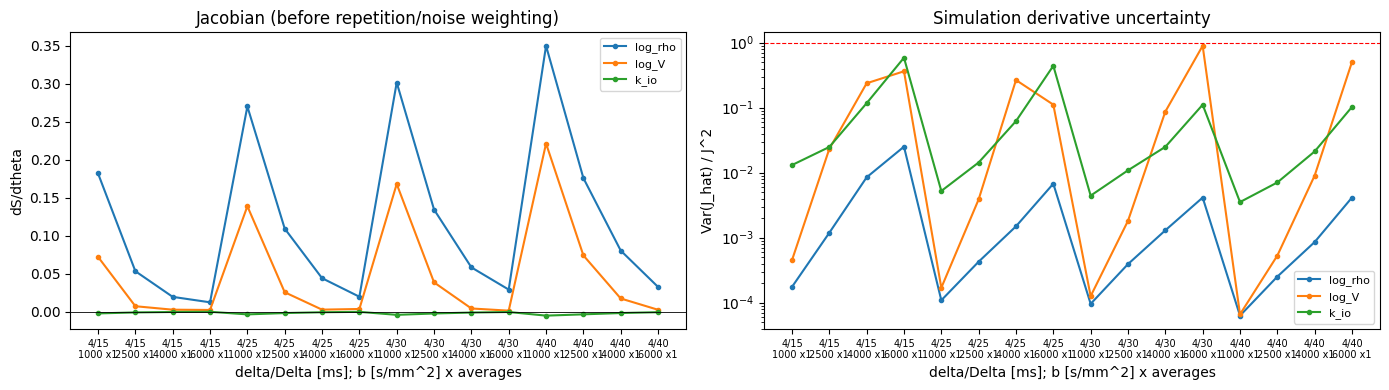

In [8]:
R = require_current_result()
print(f"{'delta':>7}{'Delta':>7}{'b':>8}{'avg':>6}{'G T/m':>10}{'signal':>10}{'sigma_avg':>12}{'keep':>7}")
for row, s, sigma, keep in zip(R['rows'], R['S'], R['sigma'], R['keep']):
    print(f"{row['delta_ms']:7.1f}{row['Delta_ms']:7.1f}{row['b_s_mm2']:8.0f}"
          f"{row['averages']:6d}{row['gradient_T_m']:10.4g}{s:10.5g}{sigma:12.5g}{str(bool(keep)):>7}")
print('\nNative F, coordinates:', PARAMETER_ORDER, '\n', R['F'])
print('\nScaled F, coordinates: (ln rho, ln V, k_io/k_ref)\n', R['F_scaled'])
print('\nSeparate corrections:')
print('MC debias diagonal:', np.diag(R['debias_correction']))
print('S0 marginalization diagonal:', np.diag(R['amplitude_correction']))
print(f"\n{'parameter':>12}{'variance bound':>18}{'SD bound':>18}{'relative SD':>18}{'kappa':>14}")
for j, label in enumerate(PARAMETER_ORDER):
    print(f"{label:>12}{R['crlb_variance'][j]:18.6g}{R['crlb_sd'][j]:18.6g}"
          f"{R['relative_crlb_sd'][j]:18.6g}{R['kappa'][j]:14.6g}")
for coords in ('native', 'scaled'):
    sp = R[coords+'_spectrum']
    print(f"\n{coords}: rank={sp['rank']}, PD={sp['positive_definite']}, "
          f"cond2={sp['condition_number']:.6g}, determinant={sp['determinant']:.6g}")
    print('lambda1 >= lambda2 >= lambda3:', sp['eigenvalues'])
    print('Eigenvectors (columns match eigenvalues):\n', sp['eigenvectors'])
    print('lambda1/lambda3:', sp['lambda1_over_lambda3'])
if not R['identifiable']:
    print('\nNo finite joint CRLB reported: scaled F is not positive definite at the stated tolerance.')

x = np.arange(len(R['rows']))
labels = [f"{r['delta_ms']:g}/{r['Delta_ms']:g}\n{r['b_s_mm2']:g} x{r['averages']}" for r in R['rows']]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for j, label in enumerate(PARAMETER_ORDER):
    ax[0].plot(x, R['J'][:, j], 'o-', ms=3, label=label)
    ax[1].semilogy(x, R['beta'][:, j], 'o-', ms=3, label=label)
ax[0].axhline(0, c='k', lw=.6); ax[1].axhline(1, c='r', ls='--', lw=.8)
ax[0].set(ylabel='dS/dtheta', title='Jacobian (before repetition/noise weighting)')
ax[1].set(ylabel='Var(J_hat) / J^2', title='Simulation derivative uncertainty')
for a in ax:
    a.set_xticks(x); a.set_xticklabels(labels, fontsize=7)
    a.set_xlabel('delta/Delta [ms]; b [s/mm^2] x averages'); a.legend(fontsize=8)
fig.tight_layout()

## 5. Append statistics to Excel or CSV

Run the next cell to append the **current computed result**. Re-running it does
not duplicate the same run ID. Re-running section 3 creates a new run ID, so
intentional repeated evaluations are retained. No protocol names are overwritten.
Excel has `protocol_stats`, `acquisition_columns`, and `definitions` sheets.
CSV contains the same wide statistics row, including the complete per-column
details as JSON. No time-normalized metrics or scan-duration fields are exported.

**Bounds:** `crlb_variance` is diag(F inverse), `crlb_sd` is its square root.
Physical rho/V bounds use the local Jacobian of exp(log parameter).
Relative SD for rho/V is the native log-coordinate SD bound; for k_io it is
the native SD divided by abs(k_io). At k_io=0 the true relative quantities are
undefined, separately from the explicitly floor-scaled version.
All eigenvectors are columns and eigenvalues are descending. Eigenvectors
within nearly repeated eigenspaces may rotate without a meaningful change.

Positive definiteness and inversion use the dimensionless scaled F and PD_RTOL.
Native numerical rank is also recorded and can differ due to coordinate units.
For singular/indefinite results, inverse entries are NaN and joint bounds are
infinite; determinant and signed spectral diagnostics are still retained.
Excel writes `NaN` and `inf` as text rather than misleading zeros.

In [9]:
DEFINITIONS = {
    'schema_version': SCHEMA_VERSION,
    'total_measurements': 'Sum of all integer averages, including b0 and masked measurements; no time normalization.',
    'used_measurements': 'Sum of averages in columns retained by signal/validity masks.',
    'n_unique_columns': 'Number of distinct (delta, Delta, b) columns after duplicate-row aggregation.',
    'n_diffusion_shells': 'Number of distinct positive b values, independent of timing; not a volume count.',
    'n_timing_shells': 'Number of distinct (delta, Delta, b>0) combinations.',
    'F_native': 'Coordinates theta=(ln rho, ln V, k_io). F entries are indexed by these coordinate names.',
    'F_scaled': 'q=(ln rho, ln V, k_io/k_ref); D=diag(1,1,k_ref), F_scaled=D F_native D.',
    'kio_ref': 'max(actual k_io, KIO_FLOOR), used only for coordinate scaling and explicitly floor-scaled bounds.',
    'Finv': 'Full inverse of final F, including off-diagonals; NaN when scaled F fails the PD tolerance.',
    'crlb_variance': 'Diagonal of native inverse F: variance lower bound in native coordinates.',
    'crlb_sd': 'Square root of crlb_variance; SD lower bound. Older notebooks called this CRLB.',
    'physical_crlb_sd': 'Local SD bound for (rho, V, k_io), using d(rho,V,k)/d(ln rho,ln V,k).',
    'physical_crlb_variance': 'Square of physical_crlb_sd.',
    'relative_crlb_sd': 'Local fractional SD: log-rho/log-V SD, and k_io SD / abs(k_io); NaN for k_io=0.',
    'relative_crlb_variance': 'Square of relative_crlb_sd.',
    'floor_relative_crlb_sd': 'SD divided by (1,1,k_ref); distinct from true relative SD at/near zero k_io.',
    'kappa': 'sqrt(F_jj * Finv_jj): SD inflation from joint estimation vs other parameters known.',
    'lambda': 'lambda1 >= lambda2 >= lambda3; eigenvectors are columns with corresponding indices.',
    'eigvec': 'eigvec_<coordinate>_lambdaN is that coordinate component of the eigenvector for lambdaN.',
    'condition_number': '2-norm condition number; lambda1/lambda3 for a symmetric positive-definite matrix.',
    'log_determinant': 'Natural log(det(F)) for numerically PD F only; not divided by measurement count.',
    'log_abs_determinant': 'Natural log(abs(det(F))), retained with determinant sign even when indefinite.',
    'status': 'PD/inverse validity assessed in scaled coordinates with relative threshold PD_RTOL.',
    'sigma_single': 'Normalized-signal noise SD for one measurement; sigma_average=sigma_single/sqrt(averages).',
    'te_mode': 'fixed: shared user TE; protocol_max: max(delta+Delta)+overhead; none: no TE penalty.',
    'estimated_min_te_ms': 'Timing estimate only: max(delta+Delta)+TE_OVERHEAD_MS.',
    'fit_s0': 'If true, common S0 is marginalized using all retained acquired rows, including explicit b0; no external S0 prior.',
    'rician_min': 'Single-measurement S/sigma threshold for Gaussian validity. This is not a Rician FIM.',
    'debias': 'Subtract weighted endpoint MC derivative variances from F diagonal, neglecting common-random-number covariance.',
    'variance_cache': 'Inherited original convention: (Vp+Vm)/(N_ENS*step^2); requires existing cache semantics.',
    'parameter_units': 'rho: cells/uL; V: pL; k_io: 1/s; delta/Delta/TE/T2: ms; b: s/mm^2; gradient: T/m.',
    'acquisitions_json': 'Resolved acquisition rows with repetitions, signal, masks, noise, Jacobians and derivative uncertainty.',
    'requested_acquisitions_json': 'Exact user input rows, before duplicate-row aggregation.',
    'F_undebiased': 'Raw J^T W J before both MC debiasing and S0 marginalization.',
    'F_debias_correction': 'Matrix subtracted for endpoint MC derivative variance.',
    'F_amplitude_correction': 'Matrix subtracted by the common S0 Schur complement.',
}

def export_rows(result):
    r = result; snap = r['snapshot']; node = r['node']
    details = []
    for i, item in enumerate(r['rows']):
        detail = dict(run_id=r['run_id'], protocol_name=snap['protocol_name'],
                      column_number=i+1, **item, signal=float(r['S'][i]),
                      sigma_single=r['sigma_1'], sigma_average=float(r['sigma'][i]),
                      kept=bool(r['keep'][i]), effective_weight=float(item['averages']/r['sigma_1']**2 if r['keep'][i] else 0))
        for j, label in enumerate(PARAMETER_ORDER):
            detail['J_'+label] = float(r['J'][i,j])
            detail['var_J_'+label] = float(r['var_J'][i,j])
            detail['beta_'+label] = float(r['beta'][i,j])
        details.append(detail)
    summary = dict(schema_version=SCHEMA_VERSION, run_id=r['run_id'],
                   timestamp_utc=r['timestamp_utc'], protocol_name=snap['protocol_name'], notes=snap['notes'],
                   configuration_key=r['configuration_key'],
                   total_measurements=r['total_measurements'], used_measurements=r['used_measurements'],
                   masked_measurements=r['total_measurements']-r['used_measurements'],
                   n_unique_columns=len(r['rows']), n_kept_columns=int(r['keep'].sum()),
                   n_timing_pairs=len({(x['delta_ms'],x['Delta_ms']) for x in r['rows']}),
                   n_distinct_b_values=len({x['b_s_mm2'] for x in r['rows']}),
                   n_diffusion_shells=len({x['b_s_mm2'] for x in r['rows'] if x['b_s_mm2']>0}),
                   n_timing_shells=sum(x['b_s_mm2']>0 for x in r['rows']),
                   n_b0_measurements=sum(x['averages'] for x in r['rows'] if x['b_s_mm2']==0),
                   requested_rho=snap['requested_node'][0], requested_V=snap['requested_node'][1],
                   requested_k_io=snap['requested_node'][2], node_index=node,
                   actual_rho=float(NODE_RHO[node]), actual_V=float(NODE_V[node]), actual_k_io=float(NODE_KIO[node]),
                   volume_fraction=float(NODE_RHO[node]*NODE_V[node]*1e-6),
                   kio_ref=r['kio_ref'], actual_te_ms=r['te_ms'], estimated_min_te_ms=r['estimated_min_te_ms'],
                   sigma_single=r['sigma_1'], status=r['status'], identifiable=r['identifiable'],
                   n_ensembles=N_ENS, library_path=str(ARTIFACT), phase1_path=str(PHASE1_DIR), cache_path=str(CACHE_DIR))
    summary.update(r['settings'])
    for j, label in enumerate(PARAMETER_ORDER):
        summary['step_'+label] = float(r['step'][j])
        for metric in ('crlb_variance','crlb_sd','physical_crlb_variance','physical_crlb_sd',
                       'relative_crlb_variance','relative_crlb_sd','floor_relative_crlb_sd','kappa'):
            summary[metric+'_'+label] = float(r[metric][j])
    matrices = {'F_native':r['F'], 'F_scaled':r['F_scaled'], 'Finv_native':r['Finv'],
                'Finv_scaled':r['Finv_scaled'], 'F_undebiased':r['F_undebiased'],
                'F_debias_correction':r['debias_correction'], 'F_amplitude_correction':r['amplitude_correction']}
    for prefix, matrix in matrices.items():
        labels = ('log_rho','log_V','k_io_scaled') if 'scaled' in prefix else PARAMETER_ORDER
        for i, a in enumerate(labels):
            for j, b in enumerate(labels):
                summary[f'{prefix}_{a}__{b}'] = float(matrix[i,j])
    for coords in ('native','scaled'):
        spec = r[coords+'_spectrum']
        labels = ('log_rho','log_V','k_io_scaled') if coords=='scaled' else PARAMETER_ORDER
        for key, val in spec.items():
            if key not in ('eigenvalues','eigenvectors'):
                summary[f'{coords}_{key}'] = val
        for j in range(3):
            summary[f'{coords}_lambda{j+1}'] = float(spec['eigenvalues'][j])
            for i, label in enumerate(labels):
                summary[f'{coords}_eigvec_{label}_lambda{j+1}'] = float(spec['eigenvectors'][i,j])
    # Strict JSON: represent nonfinite numbers as descriptive strings.
    def json_safe(obj):
        if isinstance(obj, dict): return {k:json_safe(v) for k,v in obj.items()}
        if isinstance(obj, (list,tuple)): return [json_safe(x) for x in obj]
        if isinstance(obj, float) and not math.isfinite(obj): return str(obj)
        return obj
    summary['acquisitions_json'] = json.dumps(json_safe(details), separators=(',',':'), allow_nan=False)
    summary['requested_acquisitions_json'] = json.dumps(snap['acquisitions'])
    return summary, details

def export_protocol(result, path):
    """Append a whole computed result atomically; repeated run_id is a no-op.

    Intended for one notebook writer at a time. Close an Excel workbook before
    exporting to it. Existing headers must match; use a new file after schema edits.
    """
    path = Path(path).expanduser()
    if path.suffix.lower() not in ('.csv','.xlsx'):
        raise ValueError('EXPORT_PATH must end in .csv or .xlsx')
    summary, details = export_rows(result)
    headers = list(summary)
    def sheet_value(v):
        if isinstance(v, (float,np.floating)) and not np.isfinite(v): return str(v)
        if isinstance(v, np.generic): return v.item()
        return v
    path.parent.mkdir(parents=True, exist_ok=True)
    old_rows = []
    if path.suffix.lower() == '.csv':
        if path.exists():
            with path.open(newline='', encoding='utf-8-sig') as f:
                reader = csv.DictReader(f)
                if reader.fieldnames != headers:
                    raise ValueError('Existing CSV schema differs; choose a new EXPORT_PATH')
                old_rows = list(reader)
            if any(x['run_id']==result['run_id'] for x in old_rows):
                print(f"Already exported this run: {path}"); return path
    else:
        try:
            from openpyxl import Workbook, load_workbook
            from openpyxl.styles import Font, PatternFill
        except ImportError as exc:
            raise ImportError('Install openpyxl for Excel export, or select a .csv EXPORT_PATH') from exc
        wb = load_workbook(path) if path.exists() else Workbook()
        if path.exists():
            if not {'protocol_stats','acquisition_columns','definitions'} <= set(wb.sheetnames):
                raise ValueError('Workbook is not a protocol export; choose a new path')
            ws = wb['protocol_stats']; cols = wb['acquisition_columns']
            if [x.value for x in ws[1]] != headers or [x.value for x in cols[1]] != list(details[0]):
                raise ValueError('Existing workbook schema differs; choose a new EXPORT_PATH')
            run_col = headers.index('run_id')+1
            if any(row[0]==result['run_id'] for row in ws.iter_rows(min_row=2,min_col=run_col,max_col=run_col,values_only=True)):
                wb.close(); print(f"Already exported this run: {path}"); return path
        else:
            ws = wb.active; ws.title = 'protocol_stats'
            cols = wb.create_sheet('acquisition_columns')
            defs = wb.create_sheet('definitions')
            ws.append(headers); cols.append(list(details[0])); defs.append(['field','definition'])
            for k,v in DEFINITIONS.items(): defs.append([k,v])
        # Force strings to text, so a protocol name beginning '=' isn't a formula.
        def append_safe(sheet, values):
            values = [sheet_value(v) for v in values]
            if any(isinstance(v,str) and len(v)>32767 for v in values):
                raise ValueError('A text cell exceeds Excel capacity; use CSV for this protocol')
            sheet.append(values)
            for c in sheet[sheet.max_row]:
                if isinstance(c.value,str):
                    c.data_type='s'
                elif isinstance(c.value,float): c.number_format='0.000000E+00'
        append_safe(ws, list(summary.values()))
        for row in details: append_safe(cols,list(row.values()))
        for sheet in wb:
            sheet.freeze_panes='C2' if sheet.title=='protocol_stats' else 'A2'
            sheet.auto_filter.ref=sheet.dimensions
            for c in sheet[1]:
                c.font=Font(bold=True,color='FFFFFF'); c.fill=PatternFill('solid',fgColor='244466')
                sheet.column_dimensions[c.column_letter].width=min(38,max(15,len(str(c.value))+2))
    fd, tmp = tempfile.mkstemp(prefix=path.stem+'_',suffix=path.suffix,dir=path.parent)
    os.close(fd)
    try:
        if path.suffix.lower()=='.csv':
            with open(tmp,'w',newline='',encoding='utf-8-sig') as f:
                writer=csv.DictWriter(f,fieldnames=headers)
                writer.writeheader(); writer.writerows(old_rows)
                writer.writerow({k:sheet_value(v) for k,v in summary.items()})
        else:
            wb.save(tmp); wb.close()
        os.replace(tmp,path)
    finally:
        if os.path.exists(tmp): os.unlink(tmp)
    print(f"Appended {summary['protocol_name']} ({summary['total_measurements']} measurements) to {path}")
    return path

if EXPORT_ENABLED:
    EXPORTED_PATH = export_protocol(require_current_result(), EXPORT_PATH)
else:
    print('Export disabled; set EXPORT_ENABLED=True to append the computed protocol.')

Appended four_timings_16_measurements (16 measurements) to /mnt/c/miscellaneous/coding_projects/python/mri_processing/processing/madi_gpu/custom_madi/analysis/protocol_statistics.xlsx


## 6. Heatmaps — same node, settings, and measurement budget

The selected group(s) from section 2 move to each stored `(delta, Delta)` pair;
their b-values and averages stay unchanged. All other columns stay fixed.
Selecting `"all"` sweeps a standalone timing with the same total measurements.
When moved columns coincide with fixed ones, repetition counts add.

With `TE_MODE="fixed"`, candidates exceeding the specified TE are unavailable.
With `"protocol_max"`, TE is recomputed from **all** fixed and swept columns for
each candidate, and that one TE is applied to every column of the candidate.
Missing/gradient-infeasible candidates are marked; columns are never silently
dropped. Signal masks can reduce used measurements but not the total budget.

Metrics: `crlb_variance`, `crlb_sd`, `relative_crlb_variance`, `relative_crlb_sd`,
`physical_crlb_sd`, `floor_relative_crlb_sd`, `kappa`, `lambda1`, `lambda2`,
`lambda3`, `lambda1_over_lambda3`, `lambda3_over_lambda1`, `condition_number`,
`determinant`, `log_determinant`. The coordinate selector applies to matrix metrics.
Set `HEATMAP_LOG=False` for a log-determinant map, which is already logarithmic.
No reference/difference panels or named-run registry are created.
The map is conditional on the chosen parameter node, not integrated over parameter space.

Sweep status: {'indefinite': 482, 'not_stored': 435, 'ok': 763}
Red +: fixed timings; white x: original swept timings; grey: unavailable/invalid metric.


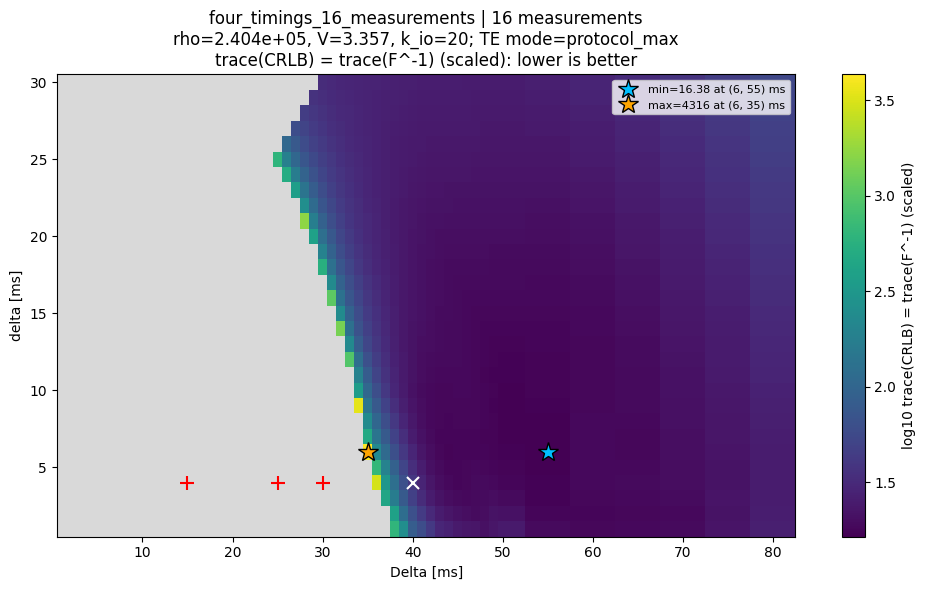

In [10]:
# Replacement for the complete final heatmap CODE cell in
# phase2_multi_delta_combined.ipynb. Requires the preceding notebook cells.
#
# In section 2, choose:
#     HEATMAP_METRIC = "trace_crlb"
#     HEATMAP_COORDINATES = "scaled"   # or "native"
# HEATMAP_PARAM is ignored for trace_crlb and other matrix metrics.
# HEATMAP_LOG=True plots log10(trace(F^-1)); HM["field"] retains the raw trace.
# Lower trace is better. Singular/indefinite cells remain masked.
# Shared TE, node, repetition counts, filtering and sweep settings are inherited.
# This replacement adds a plotting option; it does not modify Excel exports.

def heatmap_value(result, metric, param, coordinates):
    parameter_metrics = ('crlb_variance','crlb_sd','relative_crlb_variance','relative_crlb_sd',
                         'physical_crlb_sd','floor_relative_crlb_sd','kappa')
    matrix_metrics = ('lambda1','lambda2','lambda3','lambda1_over_lambda3',
                      'lambda3_over_lambda1','condition_number','determinant','log_determinant',
                      'trace_crlb')
    if metric not in parameter_metrics+matrix_metrics:
        raise ValueError(f'Unsupported heatmap metric: {metric}')
    if coordinates not in ('native','scaled'):
        raise ValueError('HEATMAP_COORDINATES must be native or scaled')
    if metric == 'trace_crlb':
        # Sum of variance bounds, not SD bounds. No fresh inversion is needed.
        # Finv_scaled uses q=(ln rho, ln V, k_io/k_ref).
        inverse_key = 'Finv_scaled' if coordinates == 'scaled' else 'Finv'
        value = float(np.trace(result[inverse_key])) if result['identifiable'] else np.inf
        return value, f'trace(CRLB) = trace(F^-1) ({coordinates})', False
    if metric in parameter_metrics:
        if param not in (0,1,2):
            raise ValueError('HEATMAP_PARAM must be 0, 1, or 2')
        value = float(result[metric][param])
        units = ('rho','V','k_io')[param] if metric=='physical_crlb_sd' else PARAMETER_ORDER[param]
        label = f'{metric}({units})'
        higher = False
    else:
        sp = result[coordinates+'_spectrum']
        value = float(sp['eigenvalues'][int(metric[-1])-1]) if metric in ('lambda1','lambda2','lambda3') else float(sp[metric])
        label = f'{metric} ({coordinates} F)'
        higher = metric not in ('condition_number','lambda1_over_lambda3')
    return value, label, higher

def sweep_protocol(result, groups, metric, param, coordinates):
    """Return a sweep result, without modifying globals or the selected protocol."""
    # Validate plot choices before entering the sweep (don't hide code/config errors).
    _, label, higher = heatmap_value(result,metric,param,coordinates)
    base = [(r['delta_ms'],r['Delta_ms'],r['b_s_mm2'],r['averages']) for r in result['rows']]
    available = {(r[0],r[1]) for r in base}
    if isinstance(groups,str):
        if groups!='all': raise ValueError('Group string must be "all"')
        selected=available
    else:
        selected={tuple(map(float,g)) for g in groups}
    if not selected or not selected <= available:
        raise ValueError(f'Sweep groups must be present in protocol. Available: {sorted(available)}')
    fixed=[r for r in base if (r[0],r[1]) not in selected]
    moving=[r for r in base if (r[0],r[1]) in selected]
    ds, Ds=np.unique(PAIR_D),np.unique(PAIR_DD)
    shape=(len(ds),len(Ds))
    field=np.full(shape,np.nan); status=np.full(shape,'not_stored',dtype=object)
    reasons=np.full(shape,'',dtype=object)
    totals=np.full(shape,np.nan); used=np.full(shape,np.nan); tes=np.full(shape,np.nan)
    for p in range(len(PAIR_D)):
        d,D=float(PAIR_D[p]),float(PAIR_DD[p])
        i,j=int(np.searchsorted(ds,d)),int(np.searchsorted(Ds,D))
        candidate=fixed+[(d,D,b,n) for _,_,b,n in moving]
        try:
            r=analyze_acquisition(result['node'],candidate,result['settings'])
        except ProtocolUnavailable as exc:
            status[i,j]='unavailable'; reasons[i,j]=str(exc); continue
        assert r['total_measurements']==result['total_measurements'], 'Sweep changed measurement budget'
        totals[i,j]=r['total_measurements']; used[i,j]=r['used_measurements']
        tes[i,j]=np.nan if r['te_ms'] is None else r['te_ms']
        if not r['identifiable']:
            status[i,j]=r['status']; continue
        val,_,_=heatmap_value(r,metric,param,coordinates)
        field[i,j]=val
        status[i,j]='ok' if np.isfinite(val) else 'undefined_metric'
    return dict(delta=ds,Delta=Ds,field=field,status=status,reasons=reasons,
                total_measurements=totals,used_measurements=used,te_ms=tes,
                label=label,higher_is_better=higher,fixed=fixed,selected=sorted(selected),
                result_run_id=result['run_id'],settings=copy.deepcopy(result['settings']))

def grid_edges(values):
    values=np.asarray(values,float)
    if len(values)==1: return np.array([values[0]-.5,values[0]+.5])
    mid=(values[1:]+values[:-1])/2
    return np.r_[2*values[0]-mid[0],mid,2*values[-1]-mid[-1]]

def plot_heatmap(hm, result, log=True, vmin=None, vmax=None, mark_extrema=True):
    field=hm['field']; valid=np.isfinite(field)
    if log:
        valid &= field>0
        plotted=np.full_like(field,np.nan)
        plotted[valid]=np.log10(field[valid])
        label='log10 '+hm['label']
    else:
        plotted=np.where(valid,field,np.nan); label=hm['label']
    cmap=plt.get_cmap('viridis').copy(); cmap.set_bad('0.85')
    fig,ax=plt.subplots(figsize=(10,6))
    pc=ax.pcolormesh(grid_edges(hm['Delta']),grid_edges(hm['delta']),
                     np.ma.masked_invalid(plotted),cmap=cmap,shading='flat',vmin=vmin,vmax=vmax)
    for d,D in {(x[0],x[1]) for x in hm['fixed']}:
        ax.plot(D,d,'r+',ms=10,mew=1.5)
    for d,D in hm['selected']:
        ax.plot(D,d,'wx',ms=8,mew=1.5)
    if mark_extrema and valid.any():
        for which,color in (('min','deepskyblue'),('max','orange')):
            f=np.where(valid,field,np.inf if which=='min' else -np.inf)
            idx=np.unravel_index(np.argmin(f) if which=='min' else np.argmax(f),f.shape)
            ax.plot(hm['Delta'][idx[1]],hm['delta'][idx[0]],'*',color=color,ms=15,mec='k',
                    label=f'{which}={field[idx]:.4g} at ({hm["delta"][idx[0]]:g}, {hm["Delta"][idx[1]]:g}) ms')
        ax.legend(fontsize=8)
    n=result['node']; settings=hm['settings']
    ax.set(xlabel='Delta [ms]',ylabel='delta [ms]',
           title=f"{result['snapshot']['protocol_name']} | {result['total_measurements']} measurements\n"
                 f"rho={NODE_RHO[n]:.4g}, V={NODE_V[n]:.4g}, k_io={NODE_KIO[n]:g}; TE mode={settings['te_mode']}\n"
                 f"{hm['label']}: {'higher' if hm['higher_is_better'] else 'lower'} is better")
    fig.colorbar(pc,ax=ax,label=label)
    fig.tight_layout()
    values,counts=np.unique(hm['status'],return_counts=True)
    print('Sweep status:',dict(zip(values,counts)))
    print('Red +: fixed timings; white x: original swept timings; grey: unavailable/invalid metric.')
    if log and np.any(np.isfinite(field)&(field<=0)):
        print('Nonpositive metric values excluded from log display; use HEATMAP_LOG=False to show them.')
    if not valid.any(): print('No finite plottable values. Inspect HM["status"] and HM["reasons"].')
    return fig

if HEATMAP_ENABLED:
    if HEATMAP_METRIC=='log_determinant' and HEATMAP_LOG:
        raise ValueError('Use HEATMAP_LOG=False when plotting log_determinant')
    R=require_current_result()
    HM=sweep_protocol(R,HEATMAP_SWEEP_GROUPS,HEATMAP_METRIC,HEATMAP_PARAM,HEATMAP_COORDINATES)
    HM_FIG=plot_heatmap(HM,R,HEATMAP_LOG,HEATMAP_VMIN,HEATMAP_VMAX,HEATMAP_MARK_EXTREMA)
else:
    print('Heatmap disabled; set HEATMAP_ENABLED=True to run the sweep.')
